# 01 — Data Preprocessing

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Data

In [16]:
df = pd.read_csv('../data/telco-customer-churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
pd.set_option('display.max_columns', None)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [18]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Drop Unnecessary Columns

In [19]:
# customerID is a unique identifier — no predictive value
df.drop(columns=['customerID'], inplace=True)
print('Shape after dropping customerID:', df.shape)

Shape after dropping customerID: (7043, 20)


## 3. Fix Data Types & Handle Nulls

In [20]:
# TotalCharges is stored as object — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Null values before drop:')
print(df.isna().sum())

Null values before drop:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [21]:
print('Rows with null TotalCharges:')
print(df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']])

Rows with null TotalCharges:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


In [22]:
# Rows with NaN TotalCharges are new customers (tenure=0)
df.dropna(subset=['TotalCharges'], inplace=True)
print('\nShape after dropping nulls:', df.shape)


Shape after dropping nulls: (7032, 20)


In [23]:
# Confirm no duplicates
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 22


## 4. Consolidate Redundant Category Values

In [24]:
# 'No internet service' and 'No phone service' are both just 'No'
# in the context of each feature — simplify them
columns_to_consolidate = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in columns_to_consolidate:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

print('Unique values after consolidation:')
for col in columns_to_consolidate:
    print(f'  {col}: {df[col].unique()}')

Unique values after consolidation:
  MultipleLines: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  OnlineSecurity: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  OnlineBackup: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
  DeviceProtection: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  TechSupport: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  StreamingTV: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  StreamingMovies: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


## 5. Encode Binary Columns

In [25]:
binary_columns = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'Churn'
]

for col in binary_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

print('Data types after encoding:')
print(df.dtypes)

Data types after encoding:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService         str
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


## 6. Class Imbalance — Inspect & Address

Class distribution:
       Count  Percentage
Churn                   
0       5163       73.42
1       1869       26.58


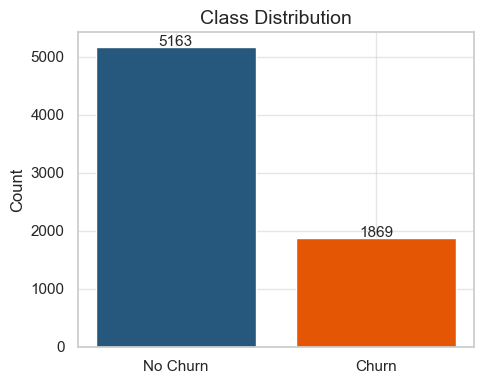

In [26]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Class distribution:')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Churn', 'Churn'], churn_counts.values, color=['#26577C', '#E55604'])
ax.set_title('Class Distribution', fontsize=14)
ax.set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Final Checks & Save

In [27]:
print('Final shape:', df.shape)
print('\nNull values:')
print(df.isna().sum())
print('\nData types:')
print(df.dtypes)
df.head()

Final shape: (7032, 20)

Null values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService         str
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [28]:
df.to_csv('../data/processed_data.csv', index=False)
print('Saved: ../data/processed_data.csv')

Saved: ../data/processed_data.csv
